# Phân Tích và Trực Quan Hóa Dữ Liệu Doanh Số Game (Video Game Sales)

Notebook này thực hiện các phân tích thống kê và trực quan hóa dữ liệu từ tập dữ liệu đã làm sạch `vgsales_clean.csv`.

### Các nội dung phân tích bao gồm:
1. **Top 10 game bán chạy nhất toàn cầu** (Horizontal Bar Chart)
2. **Doanh số theo thể loại (Genre)** - Phân tích tổng doanh số và trung bình trên mỗi đầu game
3. **Xu hướng doanh số theo năm (1980 - 2016)** - Xác định kỷ nguyên hoàng kim của ngành game
4. **Top 10 nhà phát hành (Publisher)** theo tổng doanh số
5. **So sánh cơ cấu doanh số giữa các khu vực (NA / EU / JP / Other)** theo thể loại và thị phần
6. **Phân bố doanh số theo nền tảng (Platform)**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách hiển thị biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'Segoe UI, DejaVu Sans, Arial'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.edgecolor'] = '#cbd5e1'
plt.rcParams['axes.linewidth'] = 0.8

# Tải tập dữ liệu đã làm sạch
df = pd.read_csv('vgsales_clean.csv')
print(f"Tổng số bản ghi: {len(df):,}")
df.head(5)

Tổng số bản ghi: 16,291


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 1. Top 10 Game Bán Chạy Nhất Toàn Cầu (Global Sales)
Biểu đồ thanh ngang hiển thị 10 tựa game có doanh số cao nhất mọi thời đại kèm theo nền tảng phát hành.

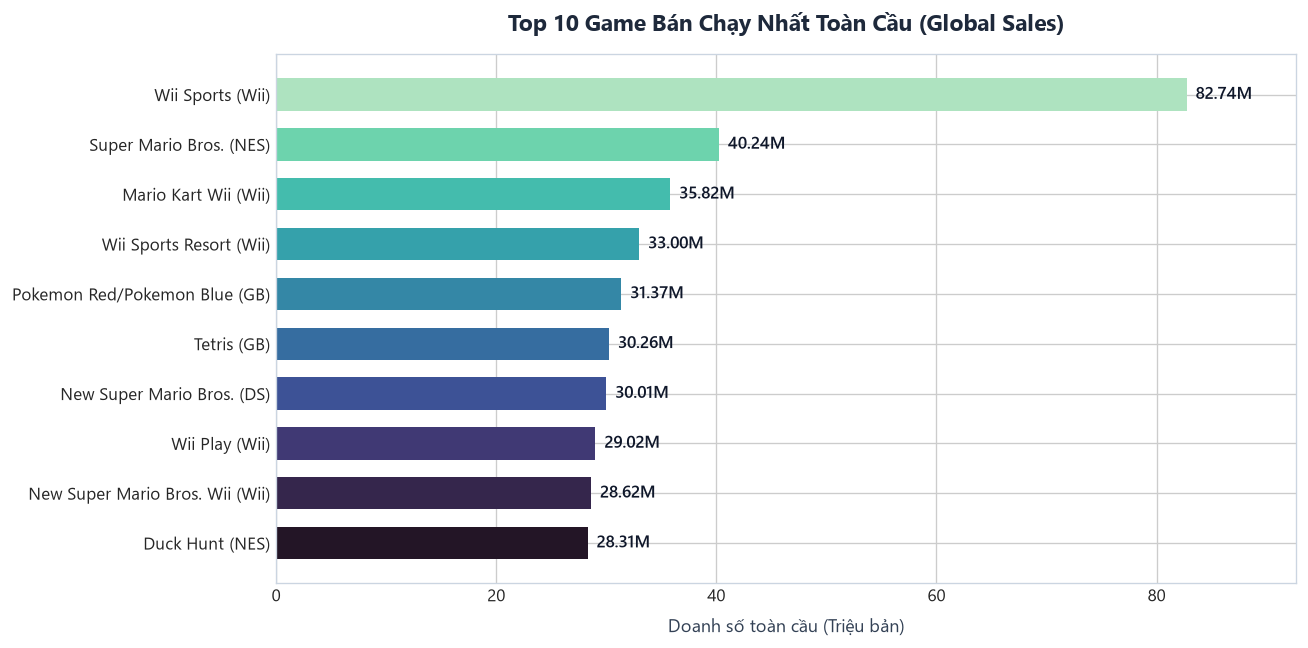

In [2]:
plt.figure(figsize=(11, 5.5))
top10 = df.head(10).copy().sort_values('Global_Sales', ascending=True)

labels = [f"{name} ({plat})" for name, plat in zip(top10['Name'], top10['Platform'])]
colors = sns.color_palette("mako", len(top10))

bars = plt.barh(labels, top10['Global_Sales'], color=colors, height=0.65)
plt.title('Top 10 Game Bán Chạy Nhất Toàn Cầu (Global Sales)', fontsize=14, fontweight='bold', pad=14, color='#1e293b')
plt.xlabel('Doanh số toàn cầu (Triệu bản)', fontsize=11, labelpad=8, color='#334155')

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.8, bar.get_y() + bar.get_height()/2, f'{w:.2f}M',
             va='center', ha='left', fontsize=10, fontweight='600', color='#0f172a')

plt.xlim(0, max(top10['Global_Sales']) * 1.12)
plt.tight_layout()
plt.show()

## 2. Doanh Số Theo Thể Loại (Genre) - Tổng và Trung Bình
So sánh hai khía cạnh:
- **Tổng doanh số:** Thể loại nào tạo ra nhiều doanh thu nhất toàn thị trường.
- **Doanh số trung bình / game:** Thể loại nào có hiệu suất thương mại trên mỗi đầu game tốt nhất.

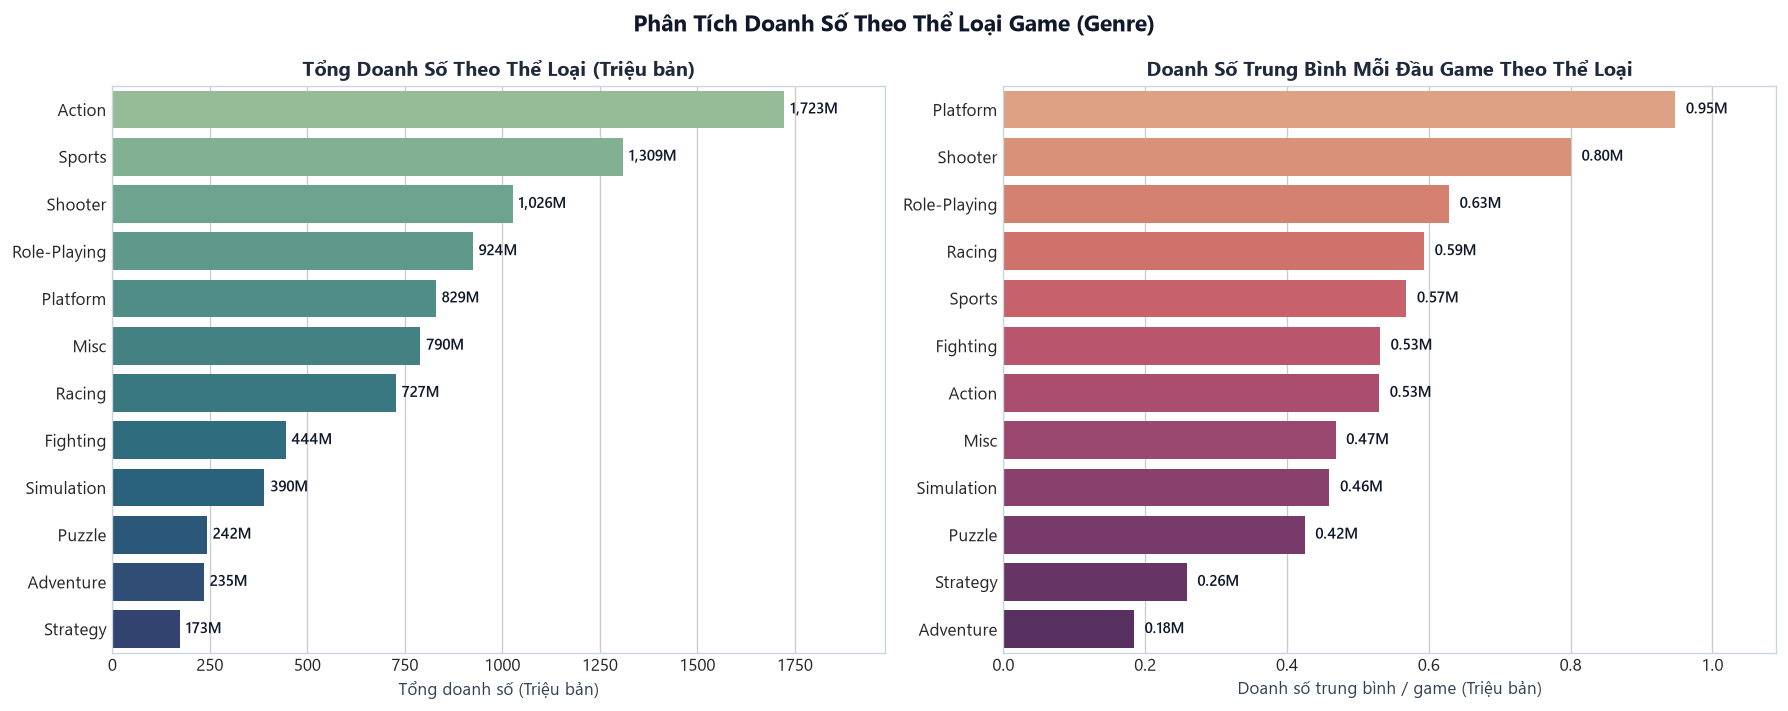

In [3]:
genre_stats = df.groupby('Genre')['Global_Sales'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Tổng doanh số
sns.barplot(x=genre_stats['sum'], y=genre_stats.index, hue=genre_stats.index, palette='crest', legend=False, ax=ax1)
ax1.set_title('Tổng Doanh Số Theo Thể Loại (Triệu bản)', fontsize=12, fontweight='bold', color='#1e293b')
ax1.set_xlabel('Tổng doanh số (Triệu bản)', fontsize=10, color='#334155')
ax1.set_ylabel('')
for bar in ax1.patches:
    w = bar.get_width()
    ax1.text(w + 15, bar.get_y() + bar.get_height()/2, f'{w:,.0f}M',
             va='center', ha='left', fontsize=9, color='#0f172a', fontweight='600')
ax1.set_xlim(0, genre_stats['sum'].max() * 1.15)

# Trung bình mỗi game
genre_avg_sorted = genre_stats.sort_values('mean', ascending=False)
sns.barplot(x=genre_avg_sorted['mean'], y=genre_avg_sorted.index, hue=genre_avg_sorted.index, palette='flare', legend=False, ax=ax2)
ax2.set_title('Doanh Số Trung Bình Mỗi Đầu Game Theo Thể Loại', fontsize=12, fontweight='bold', color='#1e293b')
ax2.set_xlabel('Doanh số trung bình / game (Triệu bản)', fontsize=10, color='#334155')
ax2.set_ylabel('')
for bar in ax2.patches:
    w = bar.get_width()
    ax2.text(w + 0.015, bar.get_y() + bar.get_height()/2, f'{w:.2f}M',
             va='center', ha='left', fontsize=9, color='#0f172a', fontweight='600')
ax2.set_xlim(0, genre_avg_sorted['mean'].max() * 1.15)

plt.suptitle('Phân Tích Doanh Số Theo Thể Loại Game (Genre)', fontsize=14, fontweight='bold', y=0.98, color='#0f172a')
plt.tight_layout()
plt.show()

## 3. Xu Hướng Doanh Số Theo Năm (1980 - 2016)
Theo dõi hành trình phát triển của ngành công nghiệp game và làm nổi bật **giai đoạn hoàng kim (2006 - 2010)**.

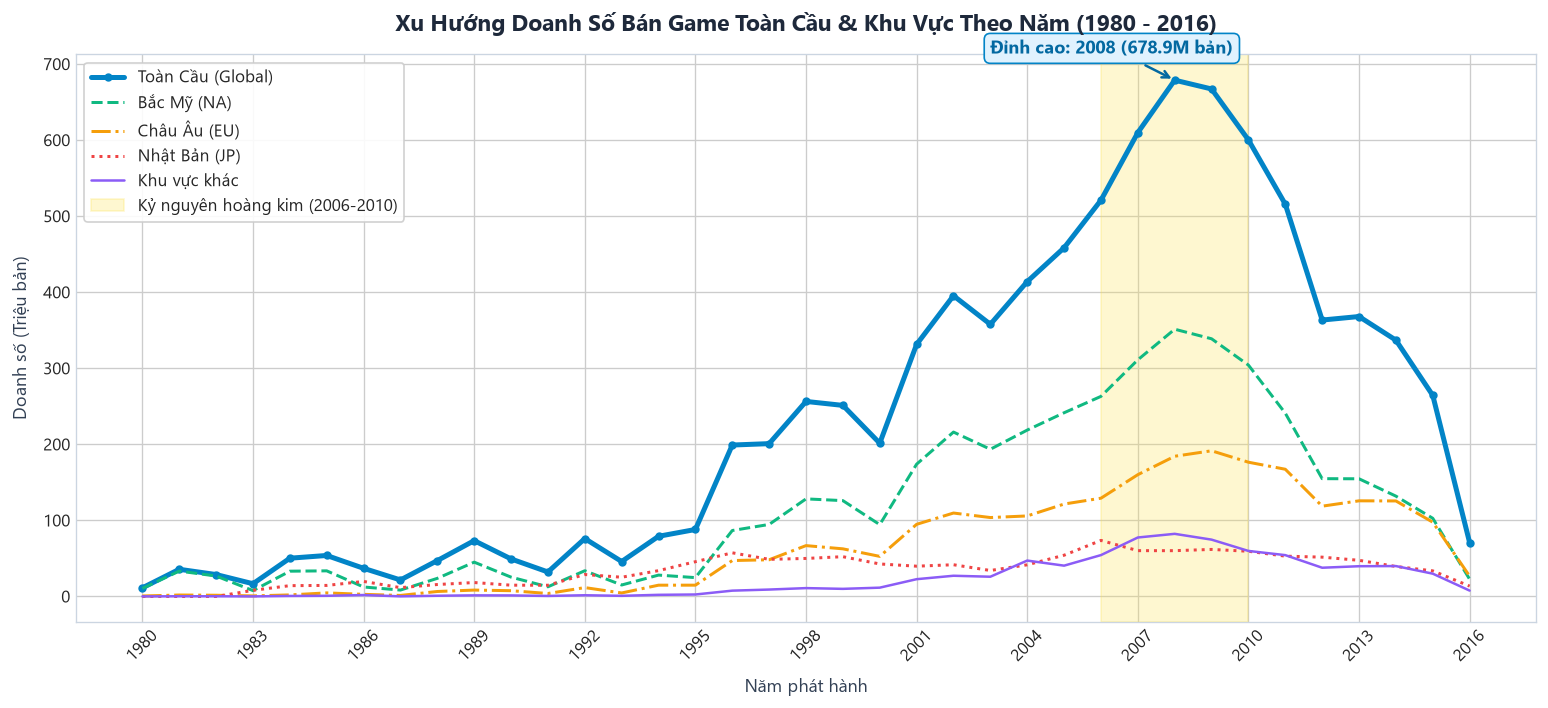

In [4]:
yearly = df[df['Year'] <= 2016].groupby('Year')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].sum()

plt.figure(figsize=(13, 6))
plt.plot(yearly.index, yearly['Global_Sales'], label='Toàn Cầu (Global)', color='#0284c7', linewidth=3, marker='o', markersize=4)
plt.plot(yearly.index, yearly['NA_Sales'], label='Bắc Mỹ (NA)', color='#10b981', linewidth=1.8, linestyle='--')
plt.plot(yearly.index, yearly['EU_Sales'], label='Châu Âu (EU)', color='#f59e0b', linewidth=1.8, linestyle='-.')
plt.plot(yearly.index, yearly['JP_Sales'], label='Nhật Bản (JP)', color='#ef4444', linewidth=1.8, linestyle=':')
plt.plot(yearly.index, yearly['Other_Sales'], label='Khu vực khác', color='#8b5cf6', linewidth=1.5)

# Đánh dấu kỷ nguyên hoàng kim
plt.axvspan(2006, 2010, color='#fde047', alpha=0.25, label='Kỷ nguyên hoàng kim (2006-2010)')

peak_yr = yearly['Global_Sales'].idxmax()
peak_val = yearly['Global_Sales'].max()
plt.annotate(f'Đỉnh cao: {peak_yr} ({peak_val:.1f}M bản)',
             xy=(peak_yr, peak_val), xytext=(peak_yr - 5, peak_val + 35),
             arrowprops=dict(arrowstyle='->', lw=1.5, color='#0369a1'),
             fontsize=10.5, fontweight='bold', color='#0369a1',
             bbox=dict(boxstyle='round,pad=0.35', facecolor='#e0f2fe', edgecolor='#0284c7'))

plt.title('Xu Hướng Doanh Số Bán Game Toàn Cầu & Khu Vực Theo Năm (1980 - 2016)', fontsize=14, fontweight='bold', pad=14, color='#1e293b')
plt.xlabel('Năm phát hành', fontsize=11, labelpad=8, color='#334155')
plt.ylabel('Doanh số (Triệu bản)', fontsize=11, labelpad=8, color='#334155')
plt.xticks(range(1980, 2017, 3), rotation=45)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

## 4. Top 10 Nhà Phát Hành (Publisher) Có Doanh Số Lớn Nhất
Xếp hạng các nhà phát hành dựa trên tổng số lượng bản game tiêu thụ trên toàn cầu.

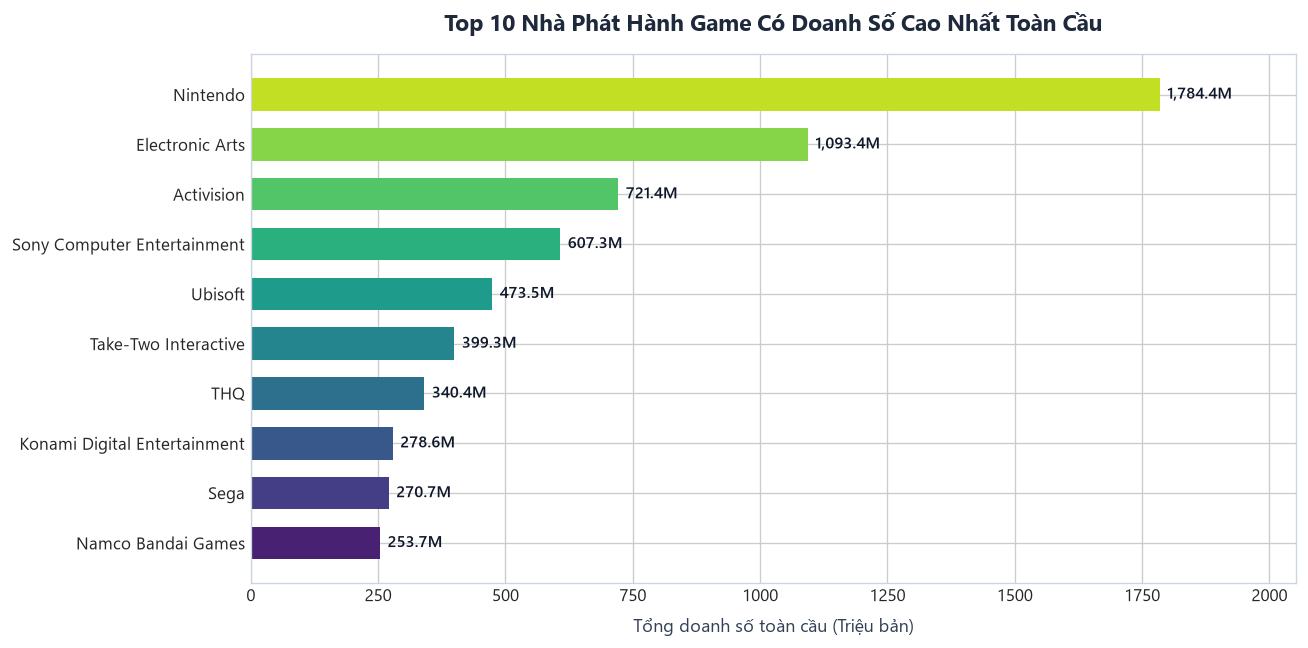

In [5]:
top_pub = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10).sort_values(ascending=True)

plt.figure(figsize=(11, 5.5))
colors_pub = sns.color_palette("viridis", len(top_pub))
bars_pub = plt.barh(top_pub.index, top_pub.values, color=colors_pub, height=0.65)

plt.title('Top 10 Nhà Phát Hành Game Có Doanh Số Cao Nhất Toàn Cầu', fontsize=14, fontweight='bold', pad=14, color='#1e293b')
plt.xlabel('Tổng doanh số toàn cầu (Triệu bản)', fontsize=11, labelpad=8, color='#334155')

for bar in bars_pub:
    w = bar.get_width()
    plt.text(w + 15, bar.get_y() + bar.get_height()/2, f'{w:,.1f}M',
             va='center', ha='left', fontsize=9.5, fontweight='600', color='#0f172a')

plt.xlim(0, top_pub.max() * 1.15)
plt.tight_layout()
plt.show()

## 5. So Sánh Doanh Số Giữa Các Khu Vực (NA / EU / JP / Other)
- **Biểu đồ cột xếp chồng:** Cơ cấu doanh số từng khu vực phân bổ theo thể loại.
- **Biểu đồ Donut:** Tỷ trọng thị phần doanh số game giữa 4 thị trường lớn trên thế giới.

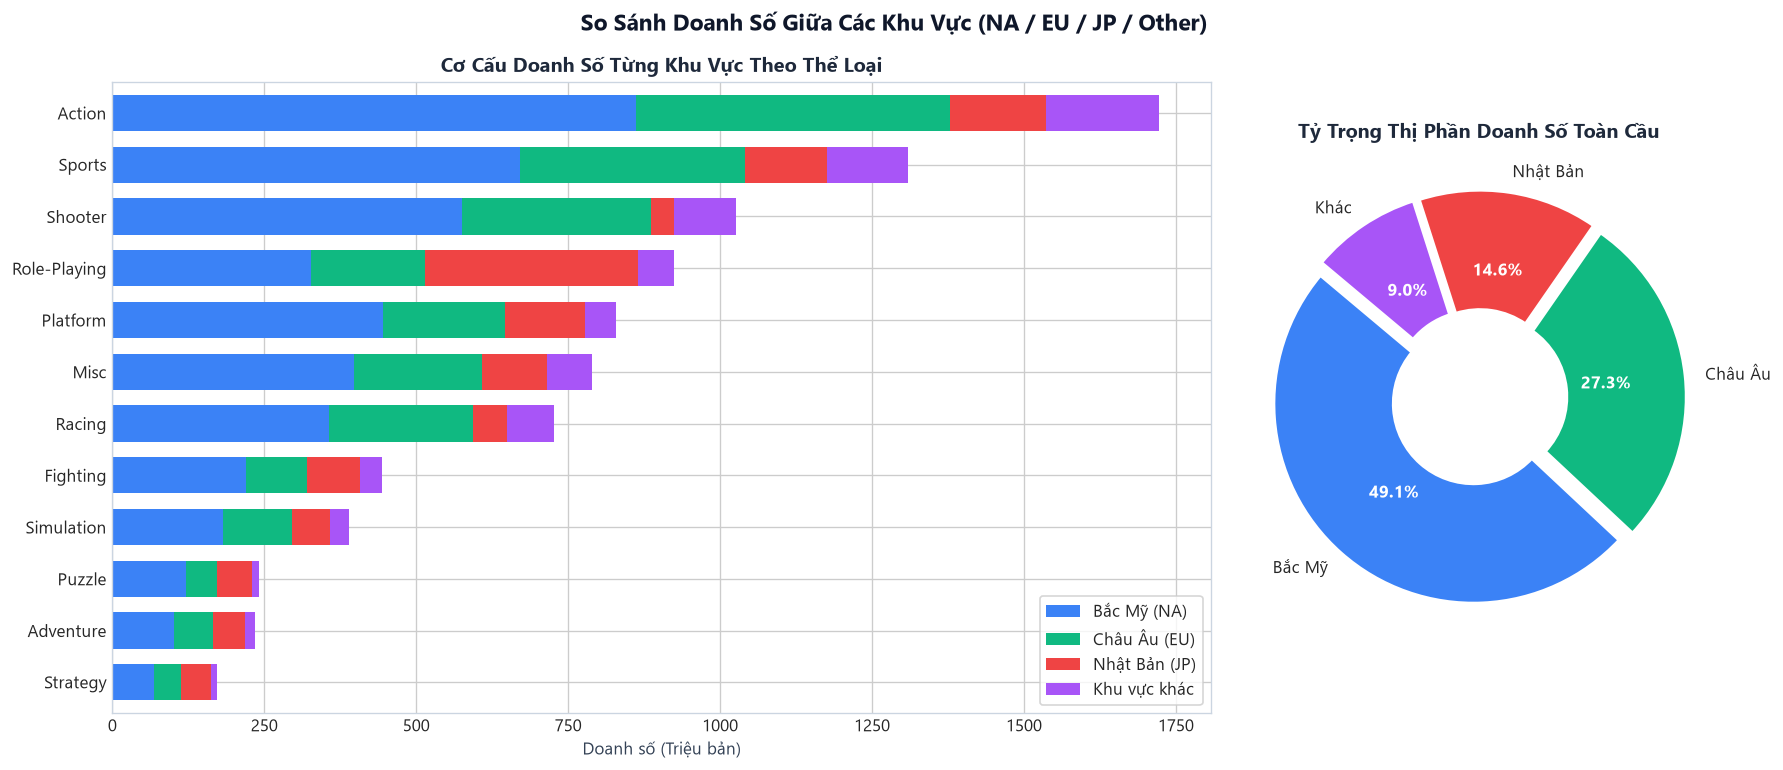

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={'width_ratios': [2.2, 1]})

genre_regional = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
genre_regional['Total'] = genre_regional.sum(axis=1)
genre_regional = genre_regional.sort_values('Total', ascending=True).drop(columns=['Total'])

genre_regional.plot(kind='barh', stacked=True, ax=ax1, color=['#3b82f6', '#10b981', '#ef4444', '#a855f7'], width=0.7)
ax1.set_title('Cơ Cấu Doanh Số Từng Khu Vực Theo Thể Loại', fontsize=12, fontweight='bold', color='#1e293b')
ax1.set_xlabel('Doanh số (Triệu bản)', fontsize=10, color='#334155')
ax1.set_ylabel('')
ax1.legend(['Bắc Mỹ (NA)', 'Châu Âu (EU)', 'Nhật Bản (JP)', 'Khu vực khác'], loc='lower right', frameon=True)

# Donut chart thị phần
total_regional = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
wedges, texts, autotexts = ax2.pie(
    total_regional,
    labels=['Bắc Mỹ', 'Châu Âu', 'Nhật Bản', 'Khác'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#3b82f6', '#10b981', '#ef4444', '#a855f7'],
    explode=(0.04, 0.04, 0.04, 0.04),
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
    at.set_fontsize(10)

ax2.set_title('Tỷ Trọng Thị Phần Doanh Số Toàn Cầu', fontsize=12, fontweight='bold', color='#1e293b')
plt.suptitle('So Sánh Doanh Số Giữa Các Khu Vực (NA / EU / JP / Other)', fontsize=14, fontweight='bold', y=0.98, color='#0f172a')
plt.tight_layout()
plt.show()

## 6. Phân Bố Doanh Số Theo Nền Tảng (Platform)
Xếp hạng 15 hệ máy console/nền tảng bán được nhiều bản game nhất trong lịch sử.

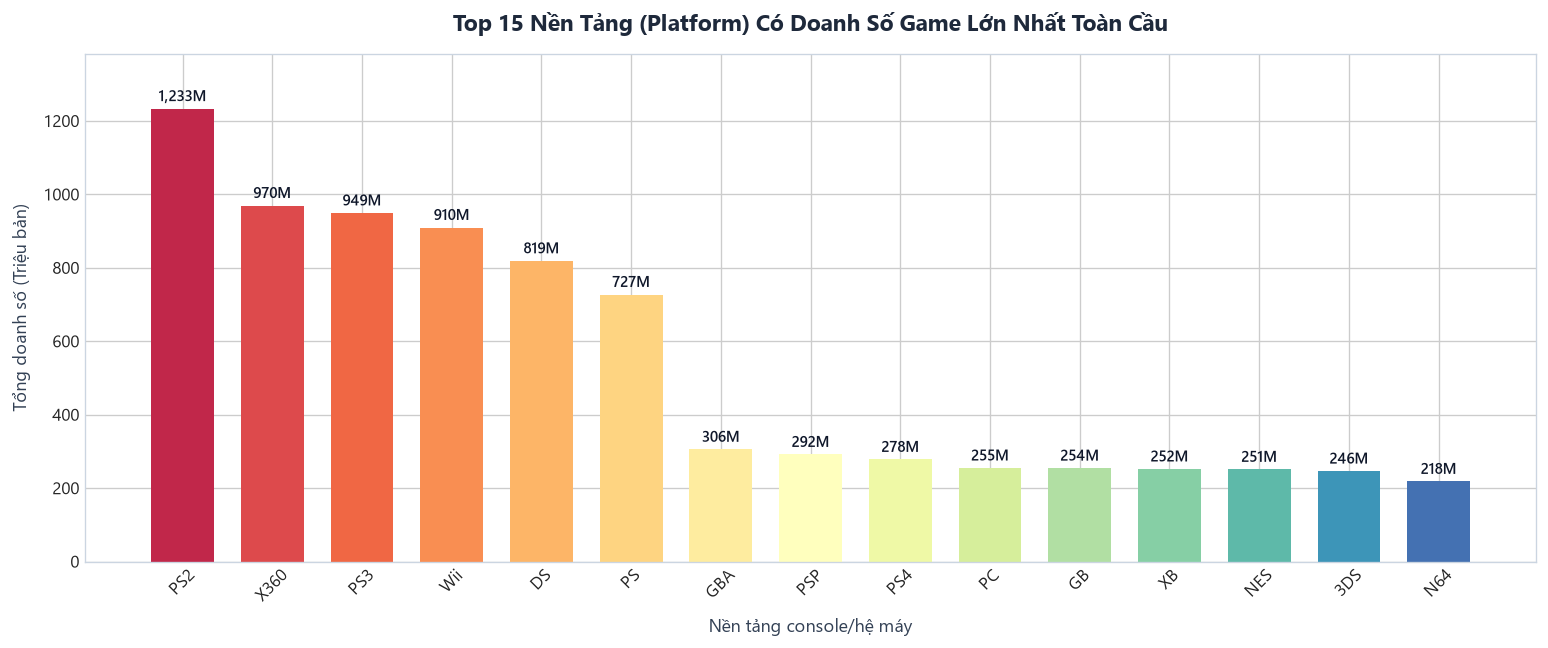

In [7]:
plt.figure(figsize=(13, 5.5))
top_plat = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(15)

palette_plat = sns.color_palette("Spectral", len(top_plat))
bars_plat = plt.bar(top_plat.index, top_plat.values, color=palette_plat, width=0.7)

plt.title('Top 15 Nền Tảng (Platform) Có Doanh Số Game Lớn Nhất Toàn Cầu', fontsize=14, fontweight='bold', pad=14, color='#1e293b')
plt.xlabel('Nền tảng console/hệ máy', fontsize=11, labelpad=8, color='#334155')
plt.ylabel('Tổng doanh số (Triệu bản)', fontsize=11, labelpad=8, color='#334155')
plt.xticks(rotation=45)

for bar in bars_plat:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 12, f'{h:,.0f}M',
             ha='center', va='bottom', fontsize=9, fontweight='600', color='#0f172a')

plt.ylim(0, top_plat.max() * 1.12)
plt.tight_layout()
plt.show()

## 7. Tổng Kết Các Insights Chính

1. **Quán quân tựa game:** `Wii Sports` (82.74M) và `Super Mario Bros.` (40.24M) là hai tựa game có sức ảnh hưởng và doanh số lớn nhất.
2. **Thể loại:** `Action` có tổng doanh số lớn nhất thị trường (1,723M), nhưng `Platform` (0.95M/game) và `Shooter` (0.80M/game) mới là thể loại có doanh số trung bình mỗi đầu game cao nhất.
3. **Kỷ nguyên hoàng kim:** Đạt đỉnh vào năm **2008 (678.9M bản)** nhờ sự cạnh tranh sôi nổi của thế hệ console thứ 7 (PS3, X360, Wii) và handheld DS.
4. **Nhà phát hành hàng đầu:** `Nintendo` (1,784M) và `Electronic Arts` (1,093M) là hai thế lực thống trị với hơn 32% thị phần toàn cầu.
5. **Đặc thù khu vực:** `Bắc Mỹ` là thị trường tiêu thụ lớn nhất (49.1%). `Nhật Bản` (14.6%) có thị hiếu rất riêng biệt khi chi tiêu phần lớn vào dòng game `Role-Playing (RPG)`.
6. **Hệ máy huyền thoại:** `PS2` (1,233M) là nền tảng bán được nhiều bản game nhất mọi thời đại, kế tiếp là `X360` (970M) và `PS3` (949M).
